---
title: Multiple Linear Regression for Time Series
---

Multiple linear regression applies to data consisting of an $n \times 1$ vector $y$ and an $n \times (m+1)$ matrix $X$ whose first column is all ones. In the (univariate) time series context, $y$ denotes the observed values of the time series. There are two ways of creating $X$: 
1. The covariates are given by various functions of the time. For example, the first covariate could be the time index, the second covariate could be the square of the time index, the third covariate could be some other function of time etc.
2. Auto-Regression: Here the covariates would be the lagged values of the observed time series. 
Here are examples of both these kinds of regressions. 

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

## Example of Regression with functions of time: USA Accidents Dataset

This dataset was inbuilt in R. I have saved it as "USAccDeaths.csv". 

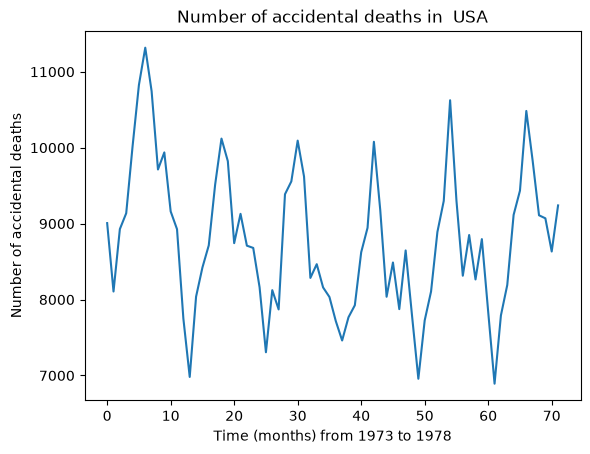

In [40]:
USAccDeaths = pd.read_csv("USAccDeaths.csv")
dt = USAccDeaths['x']
plt.plot(dt)
plt.xlabel("Time (months) from 1973 to 1978")
plt.ylabel("Number of accidental deaths")
plt.title("Number of accidental deaths in  USA")
plt.show()                

To this data, below we fit the model: 
\begin{align*}
   y_t &= \beta_0 + \beta_{11} \cos(2 \pi f_1 t/12) + \beta_{12} \sin(2 \pi f_1 t/12) \\ &+ \beta_{21} \cos(2 \pi f_2 t/12) + \beta_{22} \sin(2 \pi f_2 t/12) \\ &+ \beta_{31} \cos(2 \pi f_3 t/12) + \beta_{32} \sin(2 \pi f_3 t/12) + \epsilon_t.
\end{align*}
with fixed frequencies $f_1 = 1$, $f_2 = 2$ and $f_3 = 3$. 

                            OLS Regression Results                            
Dep. Variable:                      x   R-squared:                       0.706
Model:                            OLS   Adj. R-squared:                  0.679
Method:                 Least Squares   F-statistic:                     25.98
Date:                Tue, 08 Sep 2026   Prob (F-statistic):           1.60e-15
Time:                        18:54:09   Log-Likelihood:                -551.88
No. Observations:                  72   AIC:                             1118.
Df Residuals:                      65   BIC:                             1134.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8788.7917     63.995    137.336      0.0

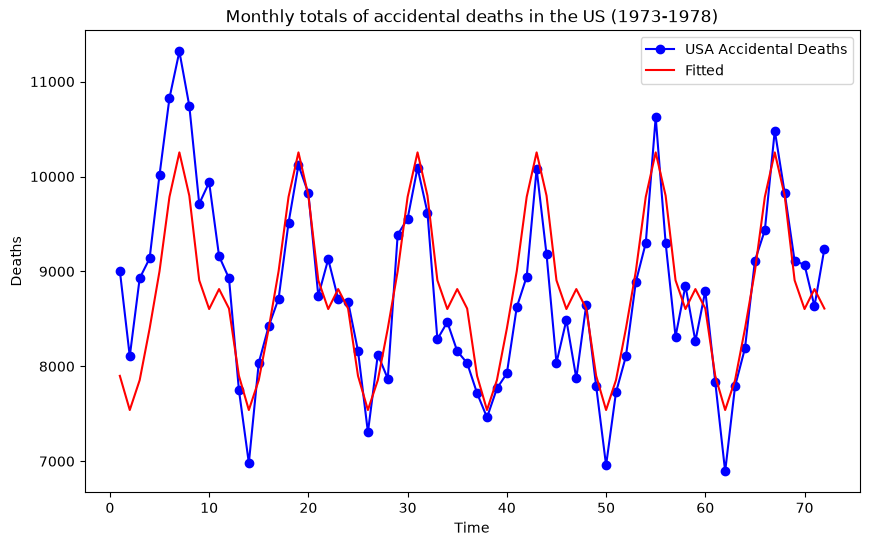

In [41]:
t = np.arange(1, len(dt) + 1)

f1, f2, f3 = 1, 2, 3
d = 12

v1 = np.cos(2 * np.pi * f1 * t/d)
v2 = np.sin(2 * np.pi * f1 * t/d)
v3 = np.cos(2 * np.pi * f2 * t/d)
v4 = np.sin(2 * np.pi * f2 * t/d)
v5 = np.cos(2 * np.pi * f3 * t/d)
v6 = np.sin(2 * np.pi * f3 * t/d)

X = np.column_stack([v1, v2, v3, v4, v5, v6])
X = sm.add_constant(X)

lin_mod = sm.OLS(dt, X).fit()
print(lin_mod.summary())

plt.figure(figsize = (10, 6))
plt.plot(t, dt, label = "USA Accidental Deaths", marker = 'o', linestyle = '-', color = 'blue')
plt.plot(t, lin_mod.fittedvalues, label = 'Fitted', color = 'red', linestyle = '-')
plt.xlabel("Time")
plt.ylabel("Deaths")
plt.title("Monthly totals of accidental deaths in the US (1973-1978)")
plt.legend()
plt.show()



                            OLS Regression Results                            
Dep. Variable:                      x   R-squared:                       0.706
Model:                            OLS   Adj. R-squared:                  0.679
Method:                 Least Squares   F-statistic:                     25.98
Date:                Tue, 08 Sep 2026   Prob (F-statistic):           1.60e-15
Time:                        18:54:39   Log-Likelihood:                -551.88
No. Observations:                  72   AIC:                             1118.
Df Residuals:                      65   BIC:                             1134.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8788.7917     63.995    137.336      0.0

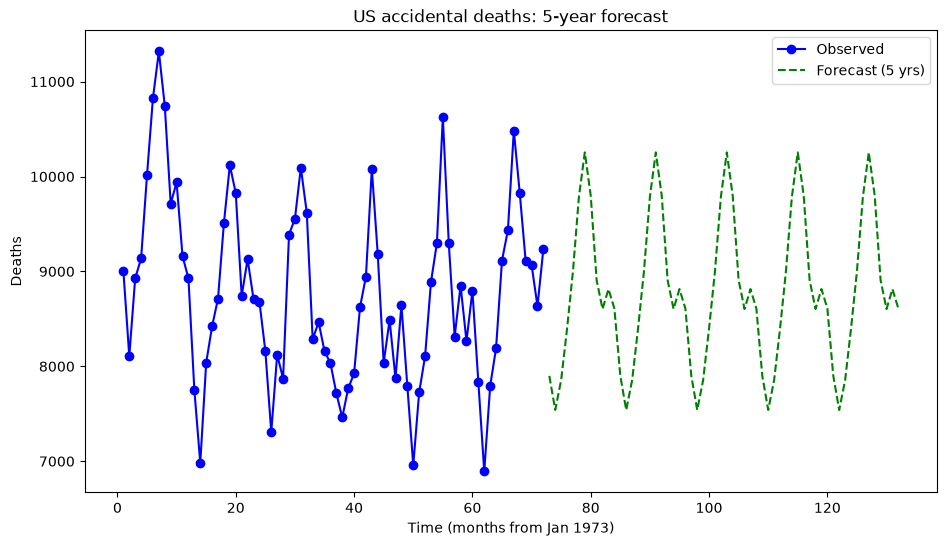

In [42]:
h = 60
n = len(dt)
t = np.arange(1, n + h + 1)            

cols = []
for k in (1, 2, 3):
    cols += [np.cos(2*np.pi*k*t/12), np.sin(2*np.pi*k*t/12)]
X = sm.add_constant(np.column_stack(cols))

mod = sm.OLS(dt, X[:n]).fit()
print(mod.summary())
pred = mod.predict(X[n:])

plt.figure(figsize=(11, 6))
plt.plot(t[:n], dt, 'o-', color='blue', label='Observed')
#plt.plot(t[:n], mod.fittedvalues, color='red', label='Fitted')
plt.plot(t[n:], pred, color='green', ls='--', label='Forecast (5 yrs)')
plt.xlabel("Time (months from Jan 1973)")
plt.ylabel("Deaths")
plt.title("US accidental deaths: 5-year forecast")
plt.legend()
plt.show()

## Example of Lagged or Auto Regression

We apply lagged regression to the following dataset. The model is: 
\begin{align*} 
   y_t = \beta_0 + \beta_1 y_{t-1} + \dots + \beta_m y_{t-m} + \epsilon_t
\end{align*}
for some $m$. The response vector and covariate matrix in this regression are: 
\begin{align*}
   y = \begin{pmatrix}y_{m+1} \\ y_{m+2} \\ \cdot \\ \cdot \\ \cdot \\ y_n \end{pmatrix} \text{ and } X = \begin{pmatrix} 1 & y_m & y_{m-1} & \cdot & \cdot & \cdot & y_1 \\
    1 & y_{m+1} & y_{m} & \cdot & \cdot & \cdot & y_2 \\
    \cdot & \cdot & \cdot & \cdot & \cdot & \cdot & \cdot \\
    \cdot & \cdot & \cdot & \cdot & \cdot & \cdot & \cdot \\
    \cdot & \cdot & \cdot & \cdot & \cdot & \cdot & \cdot \\
    1 & y_{n-1} & y_{n-2} & \cdot & \cdot & \cdot & y_{n-m}\end{pmatrix}
\end{align*}
So the number of observations in this regression is $n-m$. 

  observation_date  MRTSSM4453USN
0       1992-01-01           1414
1       1992-02-01           1444
2       1992-03-01           1496
3       1992-04-01           1569
4       1992-05-01           1707


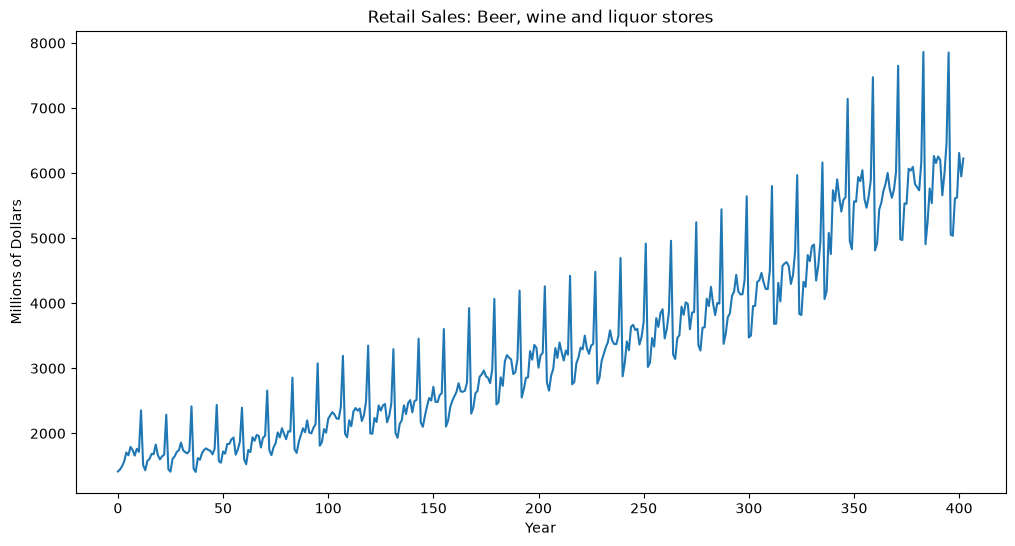

In [43]:
#The following is FRED data on retail sales (in millions of dollars) for beer, wine and liquor stores (https://fred.stlouisfed.org/series/MRTSSM4453USN)
beersales = pd.read_csv('MRTSSM4453USN_October2025.csv')
print(beersales.head())
y = beersales['MRTSSM4453USN'].to_numpy()
plt.figure(figsize = (12, 6))
plt.plot(y)
plt.xlabel('Year')
plt.ylabel('Millions of Dollars')
plt.title('Retail Sales: Beer, wine and liquor stores')
plt.show()

The code below forms $y$: $(n-m) \times 1$ and $X$: $(n-m) \times (m+1)$ as above. 

In [66]:
m = 12
n = len(y)
yreg = y[m:] #these are the response values in the autoregression
Xmat = np.ones((n-m, 1)) #this will be the design matrix (X) in the autoregression
for j in range(1, m+1):
    col = y[m-j : n-j]
    Xmat = np.column_stack([Xmat, col])
print(Xmat.shape)
print(n)

(391, 13)
403


Below we run regression (using OLS). 

In [67]:
armod = sm.OLS(yreg, Xmat).fit()
print(armod.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     2597.
Date:                Tue, 08 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:02:35   Log-Likelihood:                -2529.9
No. Observations:                 391   AIC:                             5086.
Df Residuals:                     378   BIC:                             5137.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.7819     21.711      0.312      0.7

The code below does prediction for $y_{n+1}, \dots, y_{n+k}$. This needs to be done sequentially: first predict $y_{n+1}$, then use that prediction for $y_{n+2}$ and so on. We shall study AutoRegressions in more detail later in the course. 

In [68]:
#Generate k-step ahead forecasts: 
k = 100
yhat = np.concatenate([y, np.full(k, -9999)]) #extend data by k placeholder values
for i in range(1, k+1):
    ans = armod.params[0]
    for j in range(1, m+1):
        ans += armod.params[j] * yhat[n+i-j-1]
    yhat[n+i-1] = ans
predvalues = yhat[n:]

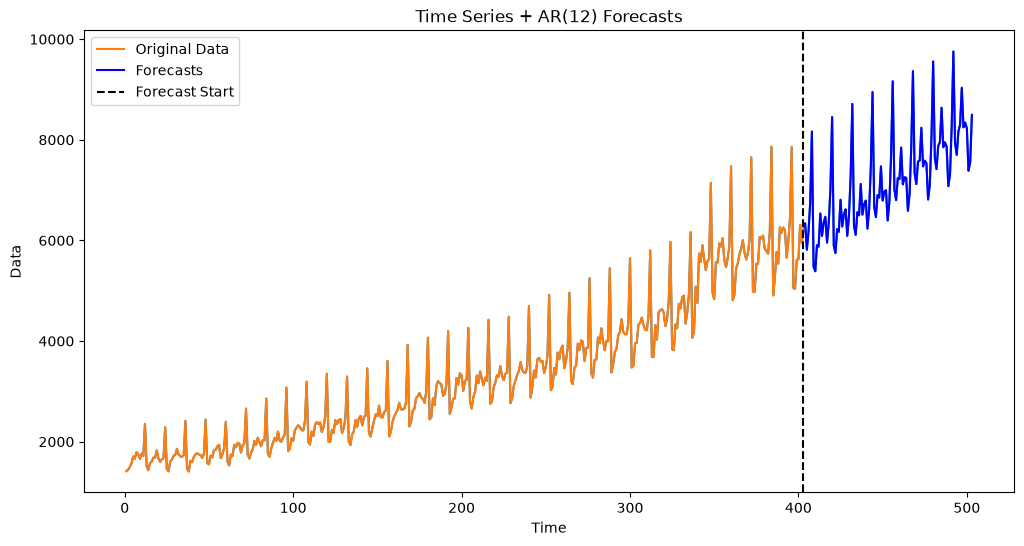

In [69]:
#Plotting the series with forecasts: 
plt.figure(figsize=(12, 6))
time_all = np.arange(1, n + k + 1)
plt.plot(time_all, yhat,  color='C0')
plt.plot(range(1, n + 1), y, label='Original Data', color='C1')
plt.plot(range(n + 1, n + k + 1), predvalues, label='Forecasts', color='blue')
plt.axvline(x=n, color='black', linestyle='--', label='Forecast Start')
#plt.axhline(y=np.mean(y), color='gray', linestyle=':', label='Mean of Original Data')
plt.xlabel('Time')
plt.ylabel('Data')
plt.title('Time Series + AR(' + str(m) + ') Forecasts')
plt.legend()
plt.show()

The value of $m$ is crucial for the performance of this method. If $m < 12$, then the predictions will look clearly off. But values of $m$ larger than 12 seem to give sensible predictions. 